# 06 — Leitura dos resultados: o que injetar, e de quem

**A grade não roda aqui.** Ela é `scripts/run_grid_v3.py`; este notebook só lê o que ele gravou e
faz os gráficos. O motivo é prático: a grade completa cruzada com limiares tem 320 condições ×
~300 itens × 2 datasets, e isso precisa rodar por `nohup`, sobreviver a um `Ctrl-C` e retomar —
coisas que um kernel de notebook não dá.

```bash
# 1. quanto vai custar, sem ligar GPU nenhuma
python scripts/run_grid_v3.py plan --grid-stage completa --thresholds 0.0 0.65 0.70

# 2. rodar (control -> grid -> materialize -> summary)
nohup python scripts/run_grid_v3.py all --grid-stage completa \
      --thresholds 0.0 0.65 0.70 > run_v3.log 2>&1 &

# triagem primeiro, se quiser gastar menos: --grid-stage triagem (k=1, pool=all)
# smoke test sem GPU:  --backend stub --limit 8 --out results/reflection_v3_smoke
```

---

## O que o `05` deixou decidido

**A qualidade do texto da reflexão não é o gargalo.** Os prompts novos funcionaram (93–100% com a
linha `Lesson:`, lições praticamente todas distintas, alucinação de gabarito de 3,5–8,7% para
0,2–0,7%) e a utility não se moveu: pareado em `threshold=0.00`, média v1 −0.0187 contra v2
−0.0199, v2 melhor em 12 de 24 pares. Os dois únicos resultados com `p < 0.05` da grade inteira
são **negativos**.

Quatro medidas apontam para "a nota age como distrator, não como professor": dose-resposta
invertida (utility cai com `k`, sobe com a fração de itens sem nota), transferability inexistente,
16–34% de troca de resposta com saldo negativo, e nenhum atributo de qualidade da lição prevendo o
resultado. O único fator que replicou nos dois datasets: notas escritas sobre respostas **corretas**
são as mais nocivas (−0.028 ARC / −0.026 LogiQA2, contra −0.005 das notas de erro).

## O que esta rodada testa

Se a nota distrai, o caminho é injetar **menos coisa e de fonte melhor**. Fatores cruzados,
mantendo `simple` × `complex`:

| fator | níveis |
|---|---|
| **conteúdo da nota** | `full` (a de hoje, ~150 palavras) · `lesson` (só a linha `Lesson:`, ~25) · `lesson_source` (lição + enunciado de origem) · `playbook` (k regras destiladas do corpus, iguais para toda questão) |
| **pool** | `all` · `errors` (só reflexões sobre respostas erradas) |
| **profundidade** | `simple` · `complex` |
| **k** | 1 · 3 |
| **limiar** | 0.00 · (opcional) quantis da similaridade |

`playbook` é o controle que separa **"o problema é a recuperação"** de **"o problema é a lição"**.
Se empatar com `lesson`, a recuperação por similaridade não agrega nada e o pipeline de embedding +
índice + limiar pode ser jogado fora. Se for *pior*, a especificidade importa e a recuperação se
justifica — seria o primeiro sinal positivo do método em quatro notebooks.

## As duas mudanças de método

**1. Uma geração por prompt distinto.** O `05` mediu ~5,6% de não-determinismo entre execuções:
prompts byte a byte idênticos ao do baseline, temperatura 0, e mesmo assim só 94,44% reproduziram a
letra. Com n=300 isso dá ±0,0136 de desvio-padrão de utility — do tamanho dos efeitos.

Flags de determinismo no vLLM atacam o sintoma; a cura é não gerar duas vezes. O script hasheia
todo prompt e gera cada um **uma vez só**. Três consequências:

- **item sem vizinho** (limiar alto) → o prompt é idêntico ao do controle, então a resposta *é* a do
  controle, copiada. Contribui exatamente 0 para a utility, que é o que conceitualmente deveria
  acontecer quando não há tratamento. No `05` esses itens contribuíam ruído nos dois sentidos, e é
  por isso que as configurações de limiar alto pareciam vencedoras;
- **condições que colidem** → `pool="errors"` é subconjunto de `all`; quando o vizinho mais próximo
  já é uma reflexão de erro, as duas montam o mesmo prompt e a segunda não gera;
- **retomada** → o cache é por hash, então reexecutar não regenera nada.

**2. O controle `k=0` é desta rodada.** A referência de toda utility é a condição sem nota gerada
neste mesmo run, não o baseline do `05` — que fica só como régua externa de quanto ruído sobrou
*entre* execuções (seção 2).


In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "scripts"))

# O script da grade e tambem o modulo com a montagem de nota, recuperacao e
# caminhos -- assim notebook e grade nao podem divergir na definicao do que e
# uma condicao.
import run_grid_v3 as g

RESULTS_V3 = ROOT / "results" / "reflection_v3"
PATHS = g.make_paths(RESULTS_V3)

GRID_STAGE = "completa"      # o mesmo que foi passado ao script
THRESHOLDS = [0.0]           # idem
STUDENTS, DATASETS, DEPTHS = g.STUDENTS, g.DATASETS, g.DEPTHS

CORPUS = g.load_corpus(DATASETS, STUDENTS)
GRID = g.make_grid(GRID_STAGE, DATASETS, STUDENTS, THRESHOLDS)

# Lido do cache, nao chutado: reconstruir um playbook com metodo diferente do que
# a grade usou exigiria `sentence_transformers` e produziria regras que nunca
# entraram em prompt nenhum.
PLAYBOOK_METHOD = g.playbook_method_used(PATHS)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 170)

# --- paleta ------------------------------------------------------------------
# Quatro slots categoricos validados para uso em TODOS os pares (dispersao,
# nao so barras adjacentes): CVD dE 9.2 no pior par, visao normal 16.3.
# A ordem e fixa por conteudo -- cor segue a entidade, nunca o ranking, entao
# filtrar condicoes nao repinta as que sobram.
CORES = {"full": "#2a78d6", "lesson": "#eb6834", "lesson_source": "#1baf7a", "playbook": "#4a3aa7"}
TINTA, TINTA2, GRADE = "#0b0b0b", "#52514e", "#d8d7d2"
plt.rcParams.update({
    "figure.figsize": (7.5, 4), "figure.dpi": 120,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRADE, "axes.labelcolor": TINTA2, "axes.titlecolor": TINTA,
    "xtick.color": TINTA2, "ytick.color": TINTA2, "grid.color": GRADE, "grid.linewidth": 0.6,
    "font.size": 9, "axes.titlesize": 10, "legend.frameon": False,
})

print(f"grid-stage={GRID_STAGE}  thresholds={THRESHOLDS}  playbook={PLAYBOOK_METHOD}  ->  {len(GRID)} condicoes")
print(f"lendo de: {RESULTS_V3}")
for nome, p in [("plano", PATHS["plan"] / "relatorio.json"),
                ("controle", PATHS["control"]), ("cache", PATHS["cache"]),
                ("summary", PATHS["diag"] / "summary_v3.csv")]:
    print(f"  {nome:9s} {'ok' if p.exists() else 'AUSENTE -- rode o script'}  {p}")


03:09:14 INFO    corpus carregado: ['arc', 'logiqa2'] | ['phi4-mini', 'llama3-8b']


grid-stage=completa  thresholds=[0.0]  playbook=kmeans  ->  128 condicoes
lendo de: c:\Users\rodri\OneDrive\Documentos\GitHub\AIIMS\papers\Reflection-MCQ\results\reflection_v3
  plano     ok  c:\Users\rodri\OneDrive\Documentos\GitHub\AIIMS\papers\Reflection-MCQ\results\reflection_v3\plan\relatorio.json
  controle  ok  c:\Users\rodri\OneDrive\Documentos\GitHub\AIIMS\papers\Reflection-MCQ\results\reflection_v3\control
  cache     ok  c:\Users\rodri\OneDrive\Documentos\GitHub\AIIMS\papers\Reflection-MCQ\results\reflection_v3\cache
  summary   ok  c:\Users\rodri\OneDrive\Documentos\GitHub\AIIMS\papers\Reflection-MCQ\results\reflection_v3\diagnostics\summary_v3.csv


## 1. Quanto a rodada custou — e quanto o reuso economizou

`plan` monta todos os prompts e os hasheia sem carregar modelo nenhum, então dá para ver o custo
antes de ligar a GPU. `reusam o controle` são os pares (condição × item) em que a busca não voltou
vizinho e o prompt ficou idêntico ao do controle — **esses não geram nada**.

Sem limiar (`--thresholds 0.0`) a busca sempre acha alguém, então a economia vem só da
deduplicação entre condições que colidem (`pool="errors"` ⊂ `pool="all"`). Com limiares no meio da
grade a economia é de outra ordem: a maior parte das condições de limiar alto é resposta de
controle copiada, o que torna a varredura de limiar quase de graça — e, mais importante, **honesta**,
porque no `05` esses itens contribuíam ruído em vez de zero.


In [2]:
rel_path = PATHS["plan"] / "relatorio.json"
plano = pd.DataFrame(json.load(rel_path.open(encoding="utf-8")))
pares, gerados, controles = (plano["pares (cond x item)"].sum(),
                             plano["prompts distintos a gerar"].sum(), plano["itens"].sum())
print(plano.to_string(index=False))
print(f"\npares condicao x item ........ {pares:,}")
print(f"geracoes de grade ............ {gerados:,}")
print(f"geracoes de controle ......... {controles:,}")
print(f"TOTAL com reuso .............. {gerados + controles:,}")
print(f"TOTAL sem reuso .............. {pares + controles:,}")
print(f"economia ..................... {100 * (1 - (gerados + controles) / (pares + controles)):.1f}%")


  student dataset  condicoes  itens  pares (cond x item)  reusam o controle  prompts distintos a gerar  geracoes economizadas  % economizado
llama3-8b     arc         80    298                23840               8812                       9646                  14194           59.5
llama3-8b logiqa2         80    300                24000               8204                       8334                  15666           65.3
phi4-mini     arc         80    298                23840               9156                       9736                  14104           59.2
phi4-mini logiqa2         80    300                24000               8056                       8809                  15191           63.3

pares condicao x item ........ 95,680
geracoes de grade ............ 36,525
geracoes de controle ......... 1,196
TOTAL com reuso .............. 37,721
TOTAL sem reuso .............. 96,876
economia ..................... 61.1%


## 2. Quanto de ruído sobrou

O controle desta rodada e o baseline do `05` respondem prompts **byte a byte idênticos**, com
temperatura 0, em execuções diferentes. O que faltar para 100% de concordância é o
não-determinismo que sobra *entre* execuções — e é a régua para saber se
`RMCQ_VLLM_DETERMINISTIC=1` pegou.

Dentro desta rodada esse ruído **não existe mais por construção**: prompt igual nunca é gerado duas
vezes. `piso_sd_utility` é o resíduo traduzido para a escala em que os efeitos são lidos; no `05`
ele era ±0.0136, do tamanho de quase todos os efeitos da grade.


In [3]:
ruido = pd.read_csv(PATHS["diag"] / "ruido_controle.csv")
print("No 05: mesma_letra 94.44%, mesmo_acerto 95.28%, piso +-0.0136\n")
print(ruido.to_string(index=False))
piso = float(ruido["piso_sd_utility"].mean())
print(f"\npiso de ruido medio: +-{piso:.4f}  ->  faixa de indiferenca ~ +-{2 * piso:.4f}")


No 05: mesma_letra 94.44%, mesmo_acerto 95.28%, piso +-0.0136

  student dataset   n  mesma_letra_pct  mesmo_acerto_pct  acc_controle_v3  acc_baseline_v2  piso_sd_utility
llama3-8b     arc 298            96.31             97.32           0.8456           0.8456           0.0095
llama3-8b logiqa2 300            94.33             96.00           0.5567           0.5500           0.0115
phi4-mini     arc 298            93.62             93.62           0.8792           0.8624           0.0146
phi4-mini logiqa2 300            84.33             90.00           0.5200           0.5333           0.0183

piso de ruido medio: +-0.0135  ->  faixa de indiferenca ~ +-0.0270


## 3. As lições, e o que o `playbook` destilou delas

Duas checagens de sanidade antes de olhar resultado. `sem licao` são as reflexões que não dá para
usar nas variantes `lesson`/`lesson_source`/`playbook` (a recuperação as pula); `licoes distintas`
perto de `n` é o que garante que não há boilerplate reciclado.


In [4]:
from rmcq.common import extract_lesson, has_lesson

licoes = pd.DataFrame([
    {
        "dataset": ds, "student": s, "depth": d,
        "n": len(CORPUS.reflections[(ds, s, d)]),
        "com Lesson: na cauda": round(100 * np.mean([has_lesson(r["reflection_text"] or "")
                                                     for r in CORPUS.reflections[(ds, s, d)].values()]), 1),
        "sem licao": sum(1 for v in CORPUS.lessons[(ds, s, d)].values() if not v),
        "palavras (mediana)": int(np.median([len(v.split()) for v in CORPUS.lessons[(ds, s, d)].values() if v] or [0])),
        "licoes distintas": len({v for v in CORPUS.lessons[(ds, s, d)].values() if v}),
        "de erro": sum(1 for r in CORPUS.reflections[(ds, s, d)].values()
                       if not (r.get("extra") or {}).get("source_was_correct")),
    }
    for ds in DATASETS for s in STUDENTS for d in DEPTHS
])
licoes


,dataset,student,depth,n,com Lesson: na cauda,sem licao,palavras (mediana),licoes distintas,de erro
0,arc,phi4-mini,simple,1109,100.0,0,16,1109,121
1,arc,phi4-mini,complex,1109,99.8,2,24,1107,121
2,arc,llama3-8b,simple,1109,92.9,79,27,1030,146
3,arc,llama3-8b,complex,1109,97.0,33,23,1076,146
4,logiqa2,phi4-mini,simple,2000,99.9,2,18,1998,935
5,logiqa2,phi4-mini,complex,2000,99.7,5,23,1995,935
6,logiqa2,llama3-8b,simple,2000,96.3,73,28,1927,900
7,logiqa2,llama3-8b,complex,2000,97.7,46,24,1954,900


In [5]:
# As regras que o playbook destilou -- leitura obrigatoria antes de interpretar
# qualquer resultado dele. Se as k regras forem quase a mesma frase, o k-means
# nao separou nada e o "playbook" e so uma licao repetida k vezes.
for p in sorted(PATHS["playbook"].glob(f"*__{PLAYBOOK_METHOD}.json"))[:4]:
    b = json.loads(p.read_text(encoding="utf-8"))
    print(f'===== {b["dataset"]}/{b["student"]}/{b["depth"]}/pool={b["pool"]}  '
          f'({b["n_licoes_no_pool"]} licoes -> {len(b["rules"])} regras) =====')
    for r in b["rules"]:
        print(f"  - {r}")
    print()


===== arc/llama3-8b/complex/pool=all  (1076 licoes -> 1 regras) =====
  - When evaluating a question about a complex phenomenon, consider multiple factors that might be relevant and weigh alternative options carefully, rather than relying on a single factor or oversimplified understanding.

===== arc/llama3-8b/complex/pool=all  (1076 licoes -> 3 regras) =====
  - Always consider multiple plausible options and evaluate the evidence for each before making a judgment.
  - When evaluating a question, consider multiple possibilities and do not rely solely on a single assumption or property.
  - When evaluating complex phenomena, consider multiple factors and their potential interactions before arriving at a conclusion, rather than relying solely on prior knowledge or a single assumption.

===== arc/llama3-8b/complex/pool=errors  (143 licoes -> 1 regras) =====
  - Consider multiple possibilities and potential outcomes, and avoid making assumptions about the question's focus based on your pri

## 4. Como cada variante fica no prompt

O mesmo item de validação, o mesmo vizinho, os quatro conteúdos lado a lado. É aqui que se vê a
razão de tamanho — `full` gasta cerca de 6× mais palavras por nota que `lesson`.


In [6]:
_cfg = {"dataset": "arc", "student": STUDENTS[0], "depth": "simple",
        "pool": "all", "k": 1, "threshold": 0.0}
_item = CORPUS.val["arc"][0]
for _c in g.CONTENTS:
    _p, _u, _s = g.prompt_for(CORPUS, PATHS, {**_cfg, "content": _c}, _item, PLAYBOOK_METHOD)
    _notas = _p.split("<notes>")[-1].split("</notes>")[0].strip() if "<notes>" in _p else "(sem nota)"
    print("=" * 100)
    print(f"### content={_c}   ({len(_p.split())} palavras no prompt, {len(_notas.split())} na nota)")
    print("=" * 100)
    print(_p)
    print()


### content=full   (294 palavras no prompt, 142 na nota)
You are answering a multiple-choice question.

First, some notes from earlier attempts at OTHER questions. They are reference material about how to reason. None of them is about the question below, and none of them contains its answer.

<notes>
<note id="1">
This note was written about a different question: "Sam builds a ramp and lets a toy car roll down. Which describes the energy of the car as it rolls down the ramp?"
The earlier answer to that question was correct.
In my previous reasoning, I realized that the car's conversion of potential energy to kinetic energy was the key factor influencing the decision. I correctly inferred that as the car descended the ramp, the energy transformation resulted in a decrease in potential energy due to the loss of height and an increase in kinetic energy due to the increase in speed. My reasoning process was accurate and led to the correct conclusion.

Lesson: Pay close attention to the tra

## 5. O resultado

`utility` = taxa de virada errado→certo menos certo→errado contra o **controle `k=0` desta
rodada**, item a item (`rmcq.stages.analyze.utility`, a mesma métrica de `analysis.ipynb`, `03`,
`04` e `05`). `utility_vs_baseline05` fica ao lado só como ponte para os números do `05`.


In [7]:
summary = pd.read_csv(PATHS["diag"] / "summary_v3.csv")
print(f"{len(summary)} condicoes\n")
cols = ["dataset", "student", "content", "pool", "depth", "k", "threshold", "utility",
        "mcnemar_p", "notas_media", "pct_reusou_controle", "palavras_de_nota", "similaridade_media"]
summary.sort_values("utility", ascending=False)[cols].head(15).round(4)


320 condicoes



,dataset,student,content,pool,depth,k,threshold,utility,mcnemar_p,notas_media,pct_reusou_controle,palavras_de_nota,similaridade_media
230,logiqa2,phi4-mini,lesson_source,errors,complex,3,0.65,0.0367,0.0433,1.2100,0.4100,170.5,0.6829
194,logiqa2,phi4-mini,lesson,all,complex,3,0.65,0.0300,0.2327,1.6833,0.2700,108.0,0.6861
185,logiqa2,phi4-mini,lesson,all,simple,1,0.65,0.0300,0.2110,0.7333,0.2667,70.5,0.7023
168,logiqa2,phi4-mini,full,all,complex,1,0.70,0.0300,0.0784,0.2633,0.7367,20.0,0.7548
200,logiqa2,phi4-mini,lesson,errors,simple,3,0.65,0.0300,0.1078,1.2133,0.4067,75.0,0.6844
184,logiqa2,phi4-mini,lesson,all,simple,1,0.00,0.0300,0.2806,1.0000,0.0000,83.0,0.6815
182,logiqa2,phi4-mini,full,errors,complex,3,0.65,0.0267,0.1686,1.2133,0.4067,255.5,0.6844
232,logiqa2,phi4-mini,playbook,all,simple,1,0.00,0.0267,0.3497,1.0000,0.0000,100.0,NaN
176,logiqa2,phi4-mini,full,errors,simple,3,0.65,0.0267,0.2153,1.2133,0.4067,249.5,0.6844
167,logiqa2,phi4-mini,full,all,complex,1,0.65,0.0267,0.3317,0.7333,0.2667,251.0,0.7023


### 5.1 O efeito de cada fator, isolado

A tabela acima é ruidosa demais para se ler linha a linha — o piso da seção 2 é o motivo. As médias
marginais agregam sobre as outras dimensões e são o que de fato responde à pergunta.

Ao ler `content`: `full` é a condição do `05` e é contra ela que as outras três têm de ganhar.
Ao ler `pool`: `errors` só conta como vitória se a `similaridade_media` não tiver despencado junto —
senão é diluição disfarçada, o mesmo artefato que fez o limiar alto parecer vencedor no `05`.


In [8]:
for fator in ["content", "pool", "depth", "k", "threshold", "dataset", "student"]:
    if summary[fator].nunique() < 2:
        continue
    print(f"===== {fator} =====")
    print(summary.groupby(fator).agg(
        n=("utility", "size"), media=("utility", "mean"), mediana=("utility", "median"),
        pior=("utility", "min"), melhor=("utility", "max"),
        similaridade=("similaridade_media", "mean"),
        palavras_nota=("palavras_de_nota", "mean"),
        reuso_controle=("pct_reusou_controle", "mean"),
    ).round(4).to_string(), "\n")

print("===== content x dataset =====")
print(summary.pivot_table(index="content", columns="dataset", values="utility",
                          aggfunc="mean").round(4).to_string())


===== content =====
                n   media  mediana    pior  melhor  similaridade  palavras_nota  reuso_controle
content                                                                                        
full           96 -0.0094  -0.0067 -0.0604  0.0300        0.6986       213.8073          0.3961
lesson         96 -0.0087  -0.0050 -0.0604  0.0300        0.6979        64.6406          0.3983
lesson_source  96 -0.0073  -0.0034 -0.0533  0.0367        0.6979       130.6042          0.3983
playbook       32 -0.0207  -0.0201 -0.0570  0.0267           NaN       118.6562          0.0000 

===== pool =====
          n   media  mediana    pior  melhor  similaridade  palavras_nota  reuso_controle
pool                                                                                     
all     160 -0.0139  -0.0167 -0.0604  0.0300        0.7074       152.5688          0.2816
errors  160 -0.0055  -0.0033 -0.0570  0.0367        0.6890       116.5938          0.4340 

===== depth =====
     

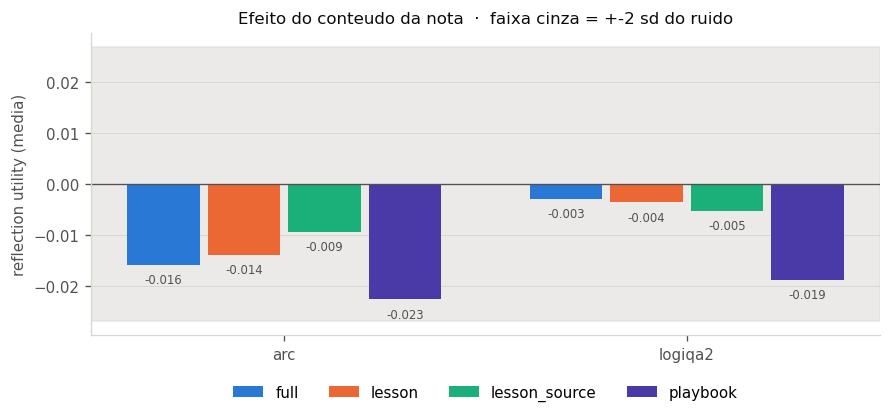

In [9]:
# Efeito marginal do conteudo da nota, por dataset. Barras agrupadas, uma cor
# por conteudo (ordem fixa), rotulo de valor em cada barra -- a regra de relevo
# para o slot de contraste baixo, e o que dispensa ler cor para saber o numero.
marg = summary.groupby(["dataset", "content"]).utility.mean().unstack("content")
marg = marg[[c for c in g.CONTENTS if c in marg.columns]]

fig, ax = plt.subplots(figsize=(7.5, 3.6))
larg = 0.8 / len(marg.columns)
x = np.arange(len(marg.index))
for j, c in enumerate(marg.columns):
    pos = x - 0.4 + larg * (j + 0.5)
    ax.bar(pos, marg[c], width=larg * 0.9, color=CORES[c], label=c)
    for xi, v in zip(pos, marg[c]):
        ax.annotate(f"{v:+.3f}", (xi, v), ha="center", fontsize=7, color=TINTA2,
                    xytext=(0, 3 if v >= 0 else -11), textcoords="offset points")
ax.axhspan(-2 * piso, 2 * piso, color=GRADE, alpha=0.5, zorder=0)
ax.axhline(0, color=TINTA2, lw=0.8)
ax.set_xticks(x, marg.index)
ax.set_ylabel("reflection utility (media)")
ax.set_title("Efeito do conteudo da nota  ·  faixa cinza = +-2 sd do ruido")
ax.legend(ncol=len(marg.columns), loc="upper center", bbox_to_anchor=(0.5, -0.12))
ax.grid(axis="y", zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


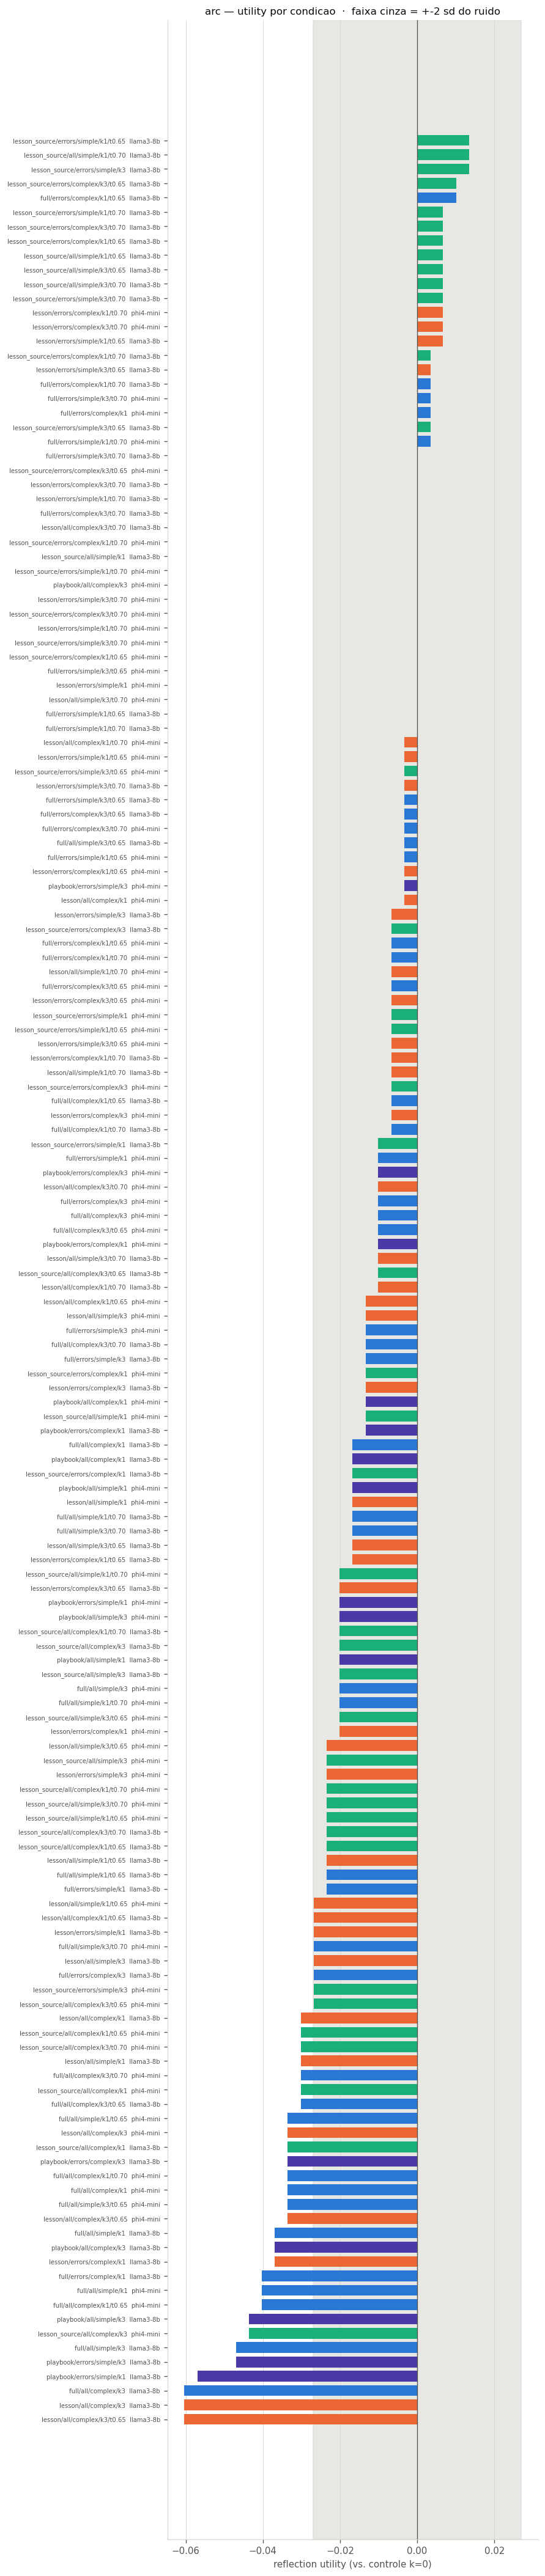

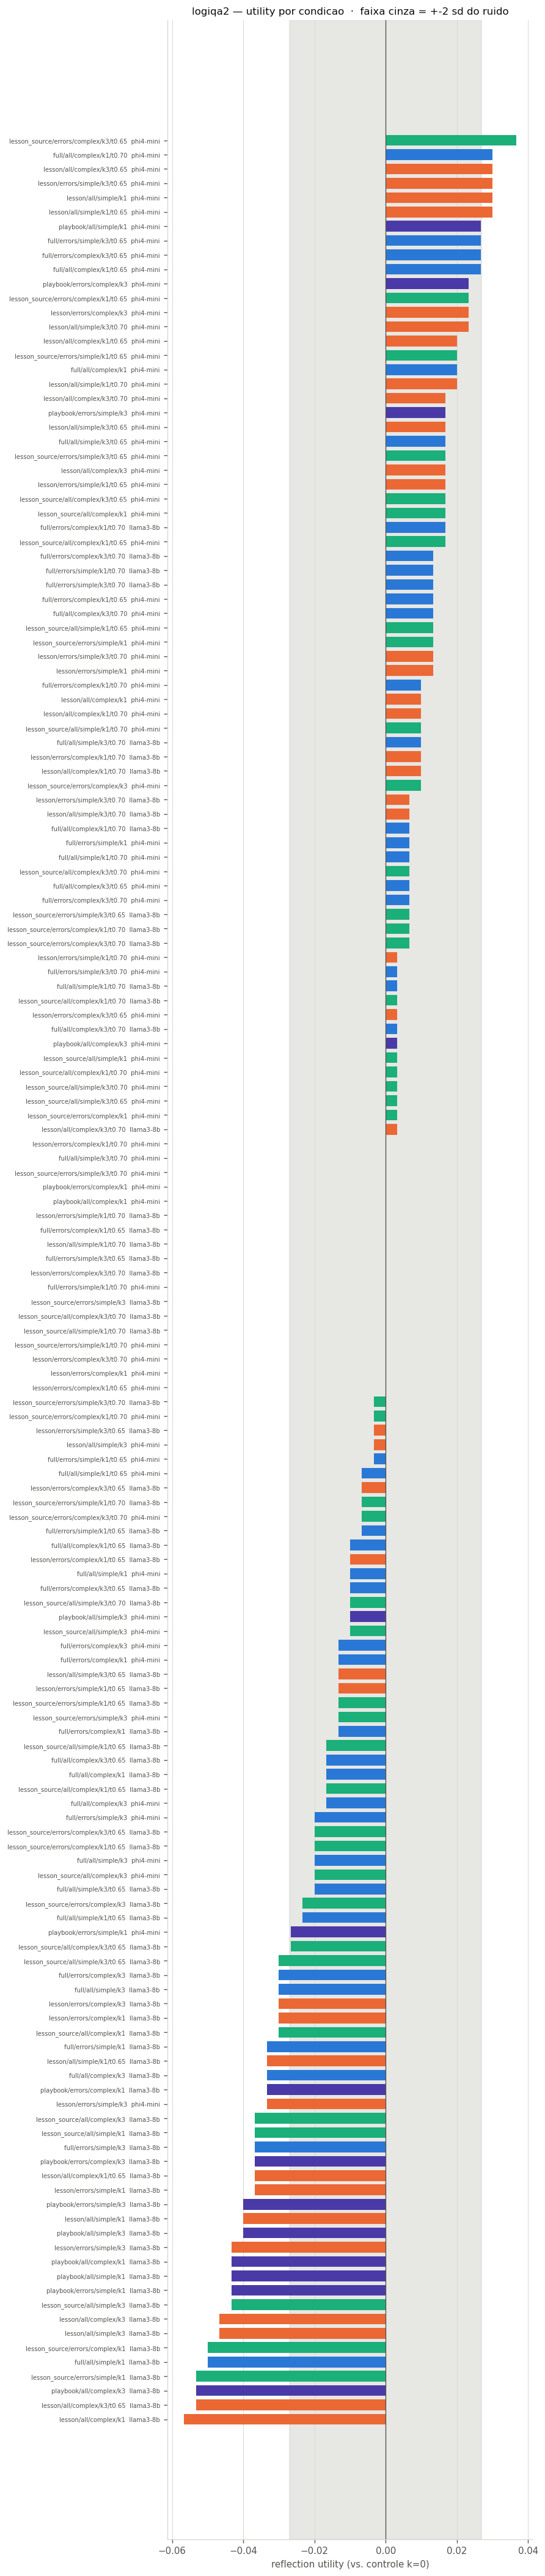

In [10]:
# Utility por condicao, ordenada, com a faixa de indiferenca por cima. Serie
# unica: sem legenda, o titulo nomeia o que esta desenhado. Qualquer barra
# dentro do cinza e indistinguivel de zero -- ler o ranking la dentro e ler ruido.
for ds in DATASETS:
    sub = summary[summary.dataset == ds].sort_values("utility")
    if sub.empty:
        continue
    rot = sub.apply(lambda r: f'{r["content"]}/{r["pool"]}/{r["depth"]}/k{r["k"]}'
                              f'{"" if r["threshold"] == 0 else "/t" + format(r["threshold"], ".2f")}'
                              f'  {r["student"]}', axis=1)
    fig, ax = plt.subplots(figsize=(7.5, max(3, 0.22 * len(sub))))
    ax.barh(np.arange(len(sub)), sub.utility,
            color=[CORES[c] for c in sub.content], height=0.75)
    ax.axvspan(-2 * piso, 2 * piso, color=GRADE, alpha=0.6, zorder=0)
    ax.axvline(0, color=TINTA2, lw=0.8)
    ax.set_yticks(np.arange(len(sub)), rot, fontsize=6)
    ax.set_xlabel("reflection utility (vs. controle k=0)")
    ax.set_title(f"{ds} — utility por condicao  ·  faixa cinza = +-2 sd do ruido")
    ax.grid(axis="x")
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()


### 5.2 Custo por ponto de acurácia

`lesson` corta a nota de ~150 para ~25 palavras. **Empate já é vitória prática** — e é a evidência
mais direta contra "reflexão mais rica ajuda mais", porque a variante mais pobre estaria fazendo o
mesmo trabalho com um sexto do contexto.


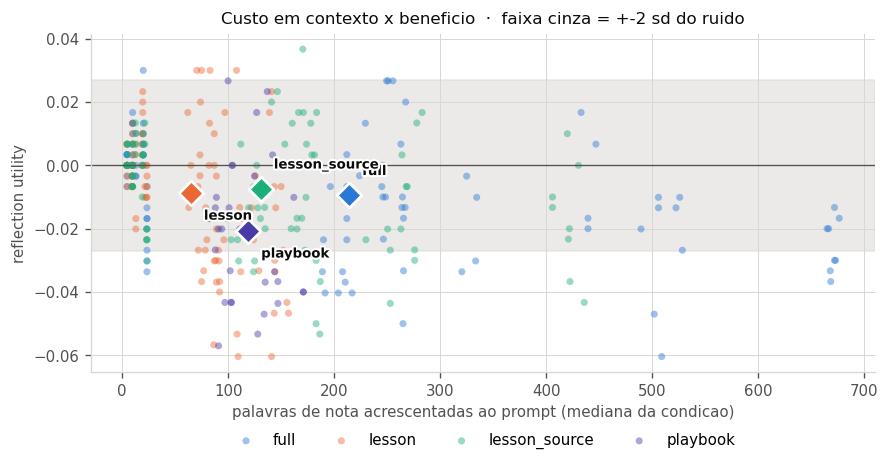

               palavras_de_nota  utility
content                                 
full                    213.807   -0.009
lesson                   64.641   -0.009
lesson_source           130.604   -0.007
playbook                118.656   -0.021


In [11]:
import matplotlib.patheffects as pe

# Cada ponto e uma condicao; o losango e a media do conteudo. Os rotulos diretos
# levam contorno branco e deslocamento alternado porque `lesson` e `playbook`
# tem quase o mesmo custo em palavras e cairiam um sobre o outro.
DESLOC = {"full": (8, 12), "lesson": (8, -16), "lesson_source": (8, 12), "playbook": (8, -16)}

fig, ax = plt.subplots(figsize=(7.5, 4))
for c in g.CONTENTS:
    sub = summary[summary.content == c]
    if sub.empty:
        continue
    ax.scatter(sub.palavras_de_nota, sub.utility, s=18, color=CORES[c], label=c,
               alpha=0.45, edgecolor="none", zorder=2)
    mx, my = sub.palavras_de_nota.mean(), sub.utility.mean()
    ax.scatter([mx], [my], s=110, color=CORES[c], marker="D",
               edgecolor="white", linewidth=1.6, zorder=4)
    ax.annotate(c, (mx, my), fontsize=8, color=TINTA, weight="bold", zorder=5,
                xytext=DESLOC[c], textcoords="offset points",
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])
ax.axhspan(-2 * piso, 2 * piso, color=GRADE, alpha=0.5, zorder=0)
ax.axhline(0, color=TINTA2, lw=0.8)
ax.set_xlabel("palavras de nota acrescentadas ao prompt (mediana da condicao)")
ax.set_ylabel("reflection utility")
ax.set_title("Custo em contexto x beneficio  ·  faixa cinza = +-2 sd do ruido")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.14))
ax.grid()
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(summary.groupby("content").agg(palavras_de_nota=("palavras_de_nota", "mean"),
                                     utility=("utility", "mean")).round(3).to_string())


## 6. Transferability

No paper original a utility deveria **cair** com a distância semântica entre a questão de validação
e a de origem da nota. No `05` a curva saiu chata e com direção invertida entre os datasets — o que
é evidência de que não havia transferência, só perturbação.

Só faz sentido para as variantes que recuperam; `playbook` injeta as mesmas regras para todo mundo
e não tem distância definida. Se a curva continuar chata **também** com `lesson`, a conclusão do
`05` se confirma num regime em que a nota é 6× menor — e aí o problema não é o quanto se injeta, é
que a recuperação por similaridade não seleciona nada de útil.


In [12]:
def carregar_condicao(cfg):
    return g.load_rows(g.cond_path(PATHS, cfg))


def carregar_controle(student, ds):
    return g.load_rows(g.control_path(PATHS, student, ds))


linhas = []
for cfg in GRID:
    if cfg["content"] == "playbook":
        continue
    cond = carregar_condicao(cfg)
    ctrl = carregar_controle(cfg["student"], cfg["dataset"])
    if not cond or not ctrl:
        continue
    for u, r in cond.items():
        sim = (r.get("extra") or {}).get("mean_similarity")
        if sim is None or u not in ctrl:
            continue
        linhas.append({"dataset": cfg["dataset"], "content": cfg["content"], "sim": sim,
                       "cond": bool(r["is_correct"]), "ctrl": bool(ctrl[u]["is_correct"])})

transf = pd.DataFrame(linhas)
FAIXAS = [0, .55, .60, .65, .70, .75, 1.0]
if not transf.empty:
    transf["faixa"] = pd.cut(transf.sim, FAIXAS)
    tab = (transf.groupby(["dataset", "content", "faixa"], observed=True)
           .apply(lambda x: pd.Series({"n": len(x), "acc_controle": x.ctrl.mean(),
                                       "acc_condicao": x.cond.mean(),
                                       "utility": x.cond.mean() - x.ctrl.mean()}),
                  include_groups=False))
    print(tab.round(4).to_string())


                                        n  acc_controle  acc_condicao  utility
dataset content       faixa                                                   
arc     full          (0.0, 0.55]   388.0        0.8454        0.8428  -0.0026
                      (0.55, 0.6]  1062.0        0.8738        0.8249  -0.0490
                      (0.6, 0.65]  1342.0        0.8346        0.8376   0.0030
                      (0.65, 0.7]  1116.0        0.8799        0.8459  -0.0341
                      (0.7, 0.75]   552.0        0.8696        0.8333  -0.0362
                      (0.75, 1.0]   308.0        0.8896        0.8506  -0.0390
        lesson        (0.0, 0.55]   389.0        0.8458        0.8278  -0.0180
                      (0.55, 0.6]  1068.0        0.8745        0.8436  -0.0309
                      (0.6, 0.65]  1351.0        0.8327        0.8305  -0.0022
                      (0.65, 0.7]  1119.0        0.8811        0.8382  -0.0429
                      (0.7, 0.75]   541.0        0.8

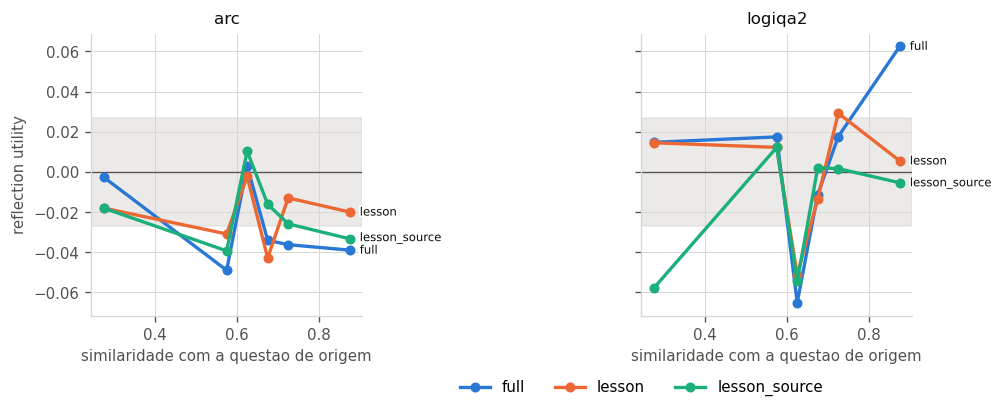

In [13]:
import matplotlib.patheffects as pe


def _espalhar(pontas, ylim, fracao=0.075):
    """Afasta rotulos que cairiam um sobre o outro, do mais baixo para o mais alto."""
    gap = fracao * (ylim[1] - ylim[0])
    saida, ultimo = [], None
    for y, x, nome in sorted(pontas):
        y_rot = y if ultimo is None else max(y, ultimo + gap)
        saida.append((y_rot, x, nome))
        ultimo = y_rot
    return saida


# Uma linha por conteudo, por dataset. Poucas series, entao legenda E rotulo
# direto na ponta -- identidade nunca so pela cor. Faixas com n < 30 sao
# omitidas: nessa contagem a barra de erro engole qualquer tendencia.
if not transf.empty:
    fig, axes = plt.subplots(1, len(DATASETS), figsize=(4.2 * len(DATASETS), 3.6), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, ds in zip(axes, DATASETS):
        sub = transf[transf.dataset == ds]
        pontas = []
        for c in g.CONTENTS:
            s = sub[sub.content == c]
            if s.empty:
                continue
            pontos = (s.groupby("faixa", observed=True)
                      .apply(lambda x: pd.Series({"n": len(x), "u": x.cond.mean() - x.ctrl.mean()}),
                             include_groups=False))
            pontos = pontos[pontos.n >= 30]
            if pontos.empty:
                continue
            xs = [iv.mid for iv in pontos.index]
            ax.plot(xs, pontos.u, marker="o", ms=5, lw=2, color=CORES[c], label=c, zorder=3)
            pontas.append((float(pontos.u.iloc[-1]), xs[-1], c))
        ax.axhspan(-2 * piso, 2 * piso, color=GRADE, alpha=0.5, zorder=0)
        ax.axhline(0, color=TINTA2, lw=0.8)
        ax.set_xlabel("similaridade com a questao de origem")
        ax.set_title(ds)
        ax.grid()
        ax.set_axisbelow(True)
        # Rotulo direto na ponta de cada linha, afastado o suficiente para nao
        # colidir: as curvas costumam terminar quase no mesmo y. O texto sai da
        # posicao real por um empurrao vertical, nunca por reposicionar o dado.
        for y_rot, x_fim, nome in _espalhar(pontas, ax.get_ylim()):
            ax.annotate(nome, (x_fim, y_rot), fontsize=7, color=TINTA, zorder=5,
                        xytext=(6, 0), textcoords="offset points", va="center",
                        path_effects=[pe.withStroke(linewidth=2.2, foreground="white")])
    axes[0].set_ylabel("reflection utility")
    axes[-1].legend(ncol=3, loc="upper center", bbox_to_anchor=(0.0, -0.18))
    plt.tight_layout()
    plt.show()


## 7. A nota de acerto continua sendo a mais nociva?

É a única regularidade que replicou nos dois datasets no `05`. Aqui ela é testada de duas formas
independentes: **por manipulação** (o fator `pool`) e **por observação** (partindo os itens de
`pool="all"` conforme a origem do que foi recuperado).

As duas concordarem é o que transforma isso de correlação em achado. Se só a observacional
aparecer, é confundimento — itens cujos vizinhos o modelo errou são itens de região difícil, e a
coluna `base_acc` mostra isso.


In [14]:
obs = []
for cfg in GRID:
    if cfg["content"] == "playbook" or cfg["pool"] != "all":
        continue
    cond = carregar_condicao(cfg)
    ctrl = carregar_controle(cfg["student"], cfg["dataset"])
    refl = CORPUS.reflections[(cfg["dataset"], cfg["student"], cfg["depth"])]
    for u, r in cond.items():
        uids = [x for x in (r.get("retrieved_uids") or []) if x in refl]
        if not uids or u not in ctrl:
            continue
        obs.append({"dataset": cfg["dataset"],
                    "frac_acerto": np.mean([bool((refl[x].get("extra") or {}).get("source_was_correct"))
                                            for x in uids]),
                    "cond": bool(r["is_correct"]), "ctrl": bool(ctrl[u]["is_correct"])})

obs = pd.DataFrame(obs)
if not obs.empty:
    obs["origem"] = pd.cut(obs.frac_acerto, [-.01, .34, .67, 1.01],
                           labels=["notas de ERRO", "misto", "notas de ACERTO"])
    print("--- observacional (dentro de pool='all') ---")
    print(obs.groupby(["dataset", "origem"], observed=True).apply(
        lambda x: pd.Series({"n": len(x), "base_acc": x.ctrl.mean(),
                             "utility": x.cond.mean() - x.ctrl.mean()}),
        include_groups=False).round(4).to_string())
    print("\nNo 05: ERRO -0.005/-0.006, ACERTO -0.028/-0.026 (ARC/LogiQA2)")

if summary.pool.nunique() > 1:
    print("\n--- por manipulacao (o fator pool) ---")
    print(summary.groupby(["dataset", "pool"]).agg(
        n=("utility", "size"), utility=("utility", "mean"),
        similaridade=("similaridade_media", "mean")).round(4).to_string())
else:
    print("\n(o fator pool so existe com GRID_STAGE='completa')")


--- observacional (dentro de pool='all') ---
                              n  base_acc  utility
dataset origem                                    
arc     notas de ERRO     728.0    0.9011  -0.0220
        misto             968.0    0.8822  -0.0227
        notas de ACERTO  5456.0    0.8537  -0.0293
logiqa2 notas de ERRO    3420.0    0.5421  -0.0284
        misto            1256.0    0.5398  -0.0231
        notas de ACERTO  2524.0    0.5325  -0.0036

No 05: ERRO -0.005/-0.006, ACERTO -0.028/-0.026 (ARC/LogiQA2)

--- por manipulacao (o fator pool) ---
                 n  utility  similaridade
dataset pool                             
arc     all     80  -0.0211        0.7106
        errors  80  -0.0068        0.6814
logiqa2 all     80  -0.0067        0.7041
        errors  80  -0.0041        0.6966


## 8. Os casos que viraram

Número agregado não diz *por que* uma nota estragou uma resposta. Abaixo, casos em que o controle
acertou e a condição errou, com a nota que o modelo leu. É a leitura que separa três diagnósticos
que os números não separam:

- lição **boa mas irrelevante** para esta questão, aplicada mesmo assim → problema de recuperação;
- lição **ruim ou enganosa** → problema de geração, e aí a conclusão do `05` estaria errada;
- lição certa e o modelo **mudou de ideia sem motivo** → a nota é ruído posicional, e nenhum
  conteúdo resolve.


In [15]:
def mostrar_viradas(dataset, student, content, pool="all", depth="simple", k=1,
                    threshold=0.0, n=3):
    cfg = {"dataset": dataset, "student": student, "content": content, "pool": pool,
           "depth": depth, "k": k, "threshold": threshold}
    cond = carregar_condicao(cfg)
    ctrl = carregar_controle(student, dataset)
    if not cond:
        print(f"(sem dados para {g.cond_tag(cfg)}/{dataset})")
        return
    virou = [u for u, r in cond.items()
             if u in ctrl and ctrl[u]["is_correct"] and r["is_correct"] is False]
    print(f"### {g.cond_tag(cfg)} / {dataset}: {len(virou)} viradas certo->errado "
          f"de {len(cond)} itens\n")
    for u in virou[:n]:
        r = cond[u]
        print("=" * 96)
        print(f"uid={u}   controle={ctrl[u]['predicted']} (certo)   "
              f"condicao={r['predicted']}   gold={r['gold']}")
        notas = (r["prompt"].split("<notes>")[-1].split("</notes>")[0].strip()
                 if "<notes>" in r["prompt"] else "(sem nota)")
        print("\n--- a nota que ele leu ---")
        print(notas[:1400])
        print("\n--- como respondeu ---")
        print((r["raw_output"] or "")[:700])
        print()


for _c in ["full", "lesson"]:
    mostrar_viradas("logiqa2", STUDENTS[0], _c, n=2)


### phi4-mini__simple__full__all__k1 / logiqa2: 36 viradas certo->errado de 300 itens

uid=logiqa2-validation-000022   controle=A (certo)   condicao=B   gold=A

--- a nota que ele leu ---
<note id="1">
This note was written about a different question: "In setting environmental standards for industry and others to meet, it is inadvisable to require the best results that state-of-the-art technology can achieve. Current technology is able to detect and eliminate even extremely minute amounts of contaminants, but at a cost that is exorbitant relative to the improvement achieved. So it would be reasonable instead to set standards by taking into account all of the current and future risks involved. The argument given concerning the reasonable way to set standards presupposes that"
The earlier answer to that question was correct.
(...) This transition from a narrow focus on technology to a broader risk-based assessment was crucial. The key factor influencing my decision was recognizing the im

## 9. Conclusões

Preencher depois da rodada real. As perguntas, na ordem:

1. **O ruído foi domado?** (seção 2) Se a concordância controle × baseline do `05` não subiu bem
   acima dos 94,44%, `RMCQ_VLLM_DETERMINISTIC` não pegou — conferir no log de carga do vLLM o aviso
   de kwargs ignorados. Isso afeta só a comparação com o `05`; *dentro* desta rodada o ruído de
   prompt repetido já não existe.

2. **Alguma variante de conteúdo bate `full`?** (seção 5.1) O resultado mais provável, dado o `05`,
   é empate técnico entre as quatro. **Empate já é informação**: 150 palavras de nota e 25 de lição
   fazendo o mesmo efeito significa que o corpo narrativo da reflexão não carrega nada, o que fecha
   de vez a hipótese "escrever reflexões melhores resolve".

3. **`playbook` empata com `lesson`?** Se sim, a recuperação por similaridade não agrega e o
   pipeline de embedding + índice + limiar pode ser substituído por uma lista fixa de regras. Se
   `playbook` for *pior*, a especificidade importa e a recuperação se justifica — seria o primeiro
   sinal positivo do método em quatro notebooks. Antes de concluir qualquer coisa aqui, reler as
   regras impressas na seção 3: se as k regras forem quase a mesma frase, o k-means não separou nada
   e o teste não vale.

4. **`errors` bate `all`?** (seção 7) Só conta como vitória se a `similaridade_media` não tiver
   despencado junto, e se manipulação e observação concordarem.

5. **A transferability apareceu?** (seção 6) Uma curva que cai com a distância, mesmo fraca, seria
   a primeira evidência de transferência real neste projeto.

6. **E se tudo empatar em zero?** Então o resultado é negativo, e é sólido: com reflexões de
   qualidade auditada (o `05` mede isso), quatro formatos de injeção, dois filtros de origem, duas
   profundidades, e um controle sem nenhum ruído de re-geração, injetar reflexões recuperadas não
   melhora modelos de 4–8B em MCQ. O contraste `05` × `06` é o que torna isso publicável — descarta
   tanto "as reflexões eram ruins" quanto "estava se injetando coisa demais".

   O eixo que continuaria sem ser isolado é **reflexão externa** (professor forte escrevendo para
   aluno fraco). As reflexões de `gpt-5-petrobras` já existem em `results/reflections/` para os
   quatro alunos, e um `07` só precisaria apontar `Corpus.reflections` para elas — o resto de
   `run_grid_v3.py` não muda.
